Usando o exemplo 499

In [1]:
%pip install pandas numpy seaborn tensorflow
%pip install nltk
%pip install lime
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from lime import lime_text
from sklearn.pipeline import make_pipeline
from tensorflow.keras import backend as K  # Importar backend do Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Layer

# Camada de Atenção (Mover para antes da definição do modelo)
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 3
        self.W = self.add_weight(name='att_W', shape=(input_shape[-1], 1), initializer='normal', trainable=True)
        self.b = self.add_weight(name='att_b', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        self.u = self.add_weight(name='att_u', shape=(input_shape[1], 1), initializer='normal', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        et = K.squeeze(K.tanh(K.dot(x, self.W) + self.b), axis=-1)
        at = K.softmax(et, axis=1)
        at = K.expand_dims(at, axis=-1)
        output = x * at
        output = K.sum(output, axis=1)
        self.attention_weights = at  # Armazenar os pesos para visualização
        return output

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        config = super().get_config().copy()
        return config

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../news_clean_onlly.csv')

In [4]:
df.head()

,Unnamed: 0,title,subject,date,Label,clean_text,label_number,char_count,word_count,avg_word_length
0,0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",Fake,donald trump just couldn t wish all americans ...,0,2620,474,5.527426
1,1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",Fake,house intelligence committee chairman devin nu...,0,1850,304,6.085526
2,2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",Fake,on friday it was revealed that former milwauke...,0,3298,564,5.847518
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",Fake,on christmas day donald trump announced that h...,0,2462,423,5.820331
4,4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",Fake,pope francis used his annual christmas day mes...,0,2292,420,5.457143


In [5]:
df.shape

(38516, 10)

<Axes: xlabel='Label', ylabel='count'>

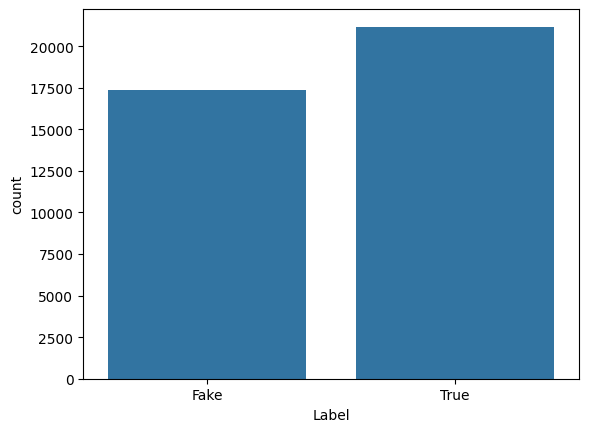

In [6]:
sns.countplot(x='Label', data = df)

**Pré-Processamento**

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["title"].apply(preprocess_text)

In [10]:
df.head(5)

,Unnamed: 0,title,subject,date,Label,clean_text,label_number,char_count,word_count,avg_word_length
0,0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",Fake,donald trump sends embarrassing new year eve m...,0,2620,474,5.527426
1,1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",Fake,drunk bragging trump staffer started russian c...,0,1850,304,6.085526
2,2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",Fake,sheriff david clarke becomes internet joke thr...,0,3298,564,5.847518
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",Fake,trump obsessed even obamas name coded website ...,0,2462,423,5.820331
4,4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",Fake,pope francis called donald trump christmas speech,0,2292,420,5.457143


<Axes: xlabel='Label', ylabel='count'>

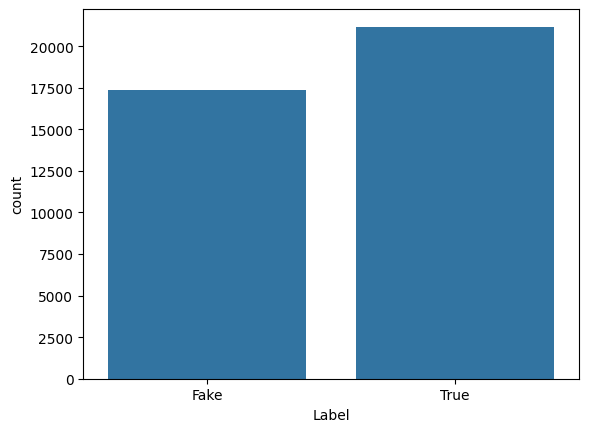

In [11]:
sns.countplot(x="Label", data=df) # validando se mudou as classes

In [12]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Label'])

In [13]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [14]:
#tokenização e padding
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

**LSTM**

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [16]:
# Definir o modelo LSTM
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(LSTM(128, return_sequences=True))  # LSTM com retorno de sequências para atenção
model.add(AttentionLayer())  # Adicionar a camada de atenção
model.add(Dense(3, activation='softmax'))  # 3 saídas para sentimentos (negativo, neutro, positivo)

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
# Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy se y_train for numérico
              metrics=['accuracy'])

In [18]:
# Treinar o modelo
history = model.fit(X_train_pad, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)  # Validação durante o treinamento

Epoch 1/10


c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\optimizers\base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['sequential/attention_layer/att_u'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


867/867 ━━━━━━━━━━━━━━━━━━━━ 323s 365ms/step - accuracy: 0.8929 - loss: 0.2442 - val_accuracy: 0.9517 - val_loss: 0.1288
Epoch 2/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 306s 353ms/step - accuracy: 0.9528 - loss: 0.1219 - val_accuracy: 0.9442 - val_loss: 0.1383
Epoch 3/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 570s 638ms/step - accuracy: 0.9660 - loss: 0.0932 - val_accuracy: 0.9484 - val_loss: 0.1267
Epoch 4/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 619s 701ms/step - accuracy: 0.9751 - loss: 0.0724 - val_accuracy: 0.9474 - val_loss: 0.1385
Epoch 5/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 591s 661ms/step - accuracy: 0.9796 - loss: 0.0578 - val_accuracy: 0.9484 - val_loss: 0.1342
Epoch 6/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 453s 463ms/step - accuracy: 0.9857 - loss: 0.0446 - val_accuracy: 0.9429 - val_loss: 0.1622
Epoch 7/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 429s 446ms/step - accuracy: 0.9891 - loss: 0.0353 - val_accuracy: 0.9500 - val_loss: 0.1623
Epoch 8/10
867/867 ━━━━━━━━━━━━━━━━━━━━ 440s 442ms/step - accuracy: 0.9916 - loss: 0.02

**Métricas**

In [19]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))


241/241 ━━━━━━━━━━━━━━━━━━━━ 35s 133ms/step
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      3504
           1       0.94      0.93      0.94      4200

    accuracy                           0.93      7704
   macro avg       0.93      0.93      0.93      7704
weighted avg       0.93      0.93      0.93      7704



In [20]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.9332
Precisão: 0.9333
Recall: 0.9332
F1-Score: 0.9332


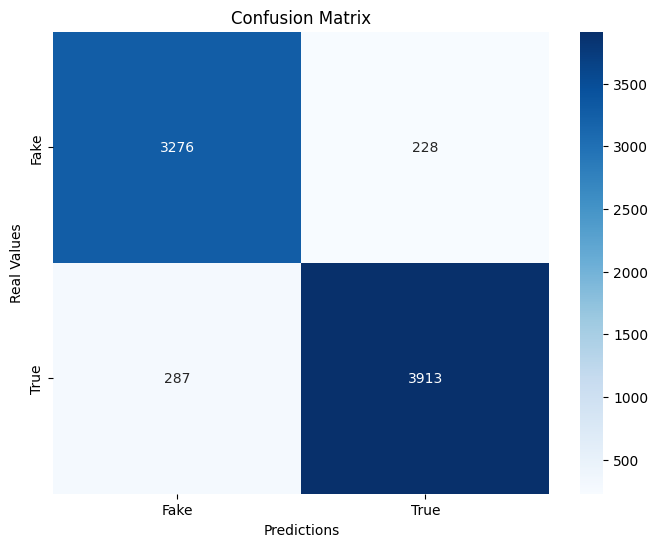

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [23]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len)
    predictions = model.predict(padded_sequences)
    return predictions  # Já retorna probabilidades (softmax)

# Solicita ao usuário o número da linha do exemplo
idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

# Predição da classe para o texto selecionado
sample_seq = tokenizer.texts_to_sequences([sample_text])
sample_pad = pad_sequences(sample_seq, maxlen=max_len)
pred_probs = model.predict(sample_pad)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step
Número da linha no X_test: 499
Original text:
party motherland north korea kim herald missile test setback
Classe real: True
Classe predita: True
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step
[(np.str_('korea'), 0.0006125930779690236), (np.str_('party'), 0.0006012184777551176), (np.str_('north'), 0.0005510438556421124), (np.str_('motherland'), -0.0004240610518959653), (np.str_('kim'), 0.00039551677699808816), (np.str_('herald'), -0.0003813878706824387), (np.str_('setback'), 0.0003696288366848177), (np.str_('missile'), 0.00034394184582395667), (np.str_('test'), 0.00025595257073010434)]


In [24]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
korea: 0.0006
party: 0.0006
north: 0.0006
motherland: -0.0004
kim: 0.0004
herald: -0.0004
setback: 0.0004
missile: 0.0003
test: 0.0003


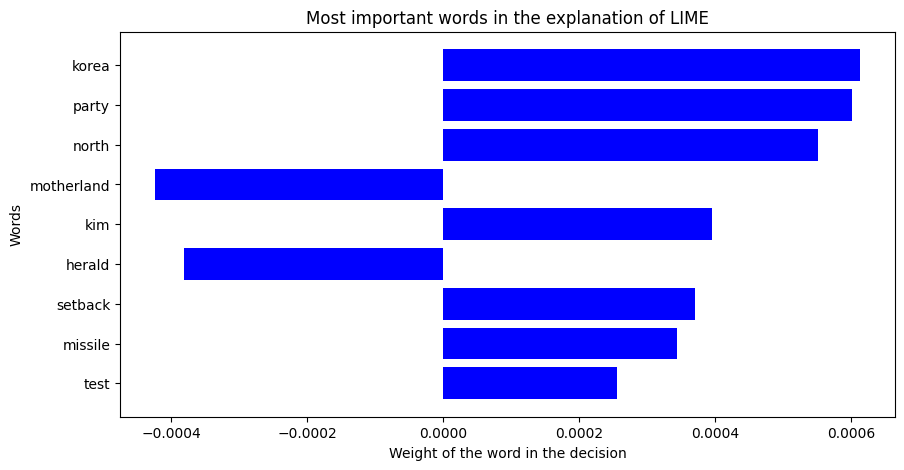

In [25]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [26]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

korea: 0.0006125930779690236
party: 0.0006012184777551176
north: 0.0005510438556421124
motherland: -0.0004240610518959653
kim: 0.00039551677699808816
herald: -0.0003813878706824387
setback: 0.0003696288366848177
missile: 0.00034394184582395667
test: 0.00025595257073010434


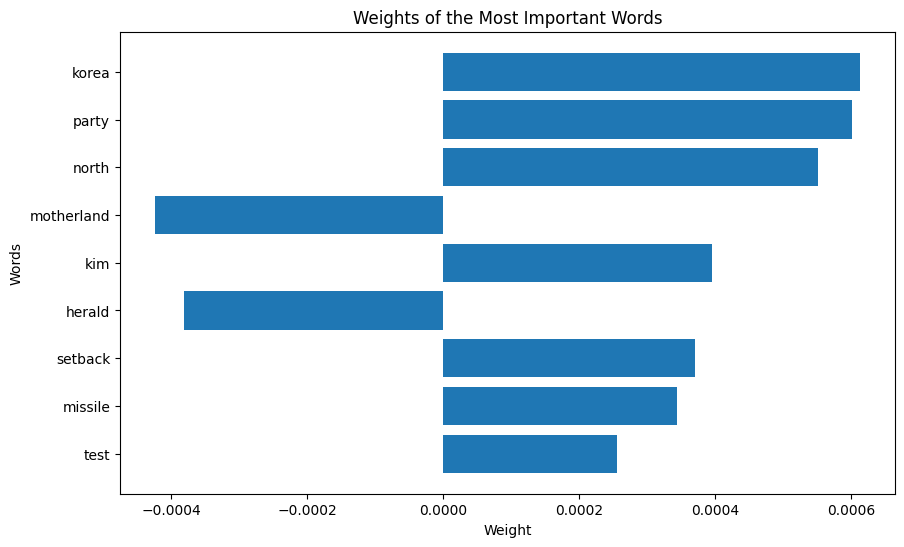

In [27]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

In [28]:
le.classes_

array(['Fake', 'True'], dtype=object)

Palavras do exemplo e seus pesos de atenção na decisão do LSTM:
   Feature    Weight
7     test  0.999961
6  missile  0.602789
8  setback  0.518421
5    <OOV>  0.289620
0    party  0.165608
4      kim  0.122514
1    <OOV>  0.062209
3    korea  0.016934
2    north  0.000000


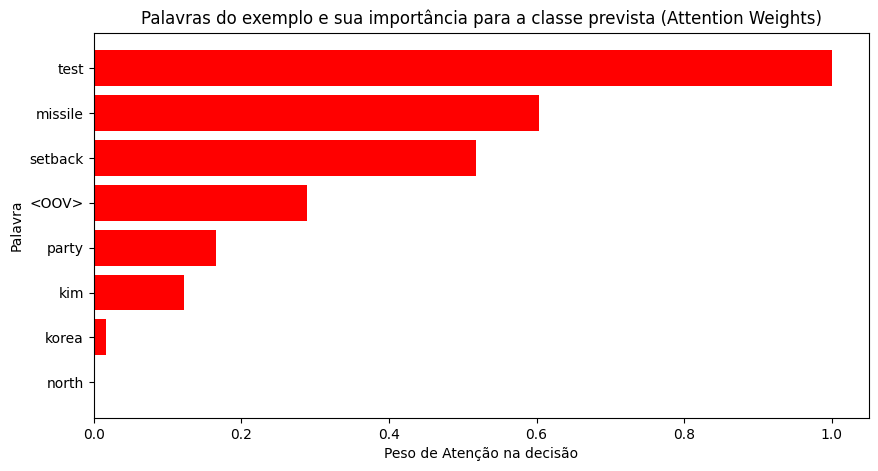

In [29]:
from tensorflow.keras.models import Model
import tensorflow as tf

# ========= 1. "Feature names" → tokens do texto (equivalente ao CountVectorizer) =========
seq = tokenizer.texts_to_sequences([sample_text])
seq_pad = pad_sequences(seq, maxlen=max_len, padding="post")

# Tokens reais do exemplo (equivalente a vect.build_analyzer())
tokens = tokenizer.sequences_to_texts(seq)[0].split()

# ========= 2. "Coeficientes" → extrair pesos de atenção =========
# Usar Model API para criar modelos intermediários
try:
    # Tentar com inputs[0]
    lstm_model = Model(
        inputs=model.inputs[0],
        outputs=model.layers[1].output  # LSTM output
    )
    lstm_output = lstm_model.predict(seq_pad, verbose=0)
except:
    # Fallback: fazer previsão direta e extrair via função customizada
    # Criar uma função que retorna a saída do LSTM
    lstm_layer = model.layers[1]
    
    # Usar a previsão normal e extrair via submodelo
    def get_lstm_output(x):
        embedding = model.layers[0](x)
        lstm_out = model.layers[1](embedding)
        return lstm_out
    
    lstm_output = get_lstm_output(seq_pad).numpy()

# Extrair pesos da camada de atenção
attention_layer = model.layers[2]  # AttentionLayer está no índice 2

# Obter os pesos treinados
W = attention_layer.W.numpy()
b = attention_layer.b.numpy()

# Calcular pesos de atenção manualmente usando a fórmula da camada AttentionLayer
# et = tanh(x @ W + b), at = softmax(et)
et = np.squeeze(np.tanh(np.dot(lstm_output[0], W) + b), axis=-1)
at = np.exp(et - np.max(et)) / np.sum(np.exp(et - np.max(et)), axis=0)  # softmax

# Remover padding: pegar apenas os pesos das sequências reais
num_real_tokens = len(tokens)
pesos_atencao = at[-num_real_tokens:].flatten()[:num_real_tokens]

# Normalizar os pesos para comparabilidade com SVM
pesos_atencao = (pesos_atencao - pesos_atencao.min()) / (pesos_atencao.max() - pesos_atencao.min() + 1e-8)

# ========= 3. Criar DataFrame (equivalente ao SVM) =========
importancias = pd.DataFrame({
    "Feature": tokens,
    "Weight": pesos_atencao
})

# ========= 4. Marcar palavras do exemplo (todas são do exemplo no LSTM) =========
importancias["No_Exemplo"] = True

# ========= 5. Ordenar por importância =========
importancias_exemplo = importancias.sort_values(
    by="Weight",
    ascending=False
)

print("Palavras do exemplo e seus pesos de atenção na decisão do LSTM:")
print(importancias_exemplo[["Feature", "Weight"]])

# ========= 6. Plotar (mesmo estilo do SVM) =========
plt.figure(figsize=(10, 5))
plt.barh(
    importancias_exemplo["Feature"],
    importancias_exemplo["Weight"],
    color="red"
)
plt.xlabel("Peso de Atenção na decisão")
plt.ylabel("Palavra")
plt.title("Palavras do exemplo e sua importância para a classe prevista (Attention Weights)")
plt.gca().invert_yaxis()
plt.show()


Shapley

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step
6513/6513 ━━━━━━━━━━━━━━━━━━━━ 1352s 208ms/step


100%|██████████| 1/1 [22:58<00:00, 1378.33s/it]


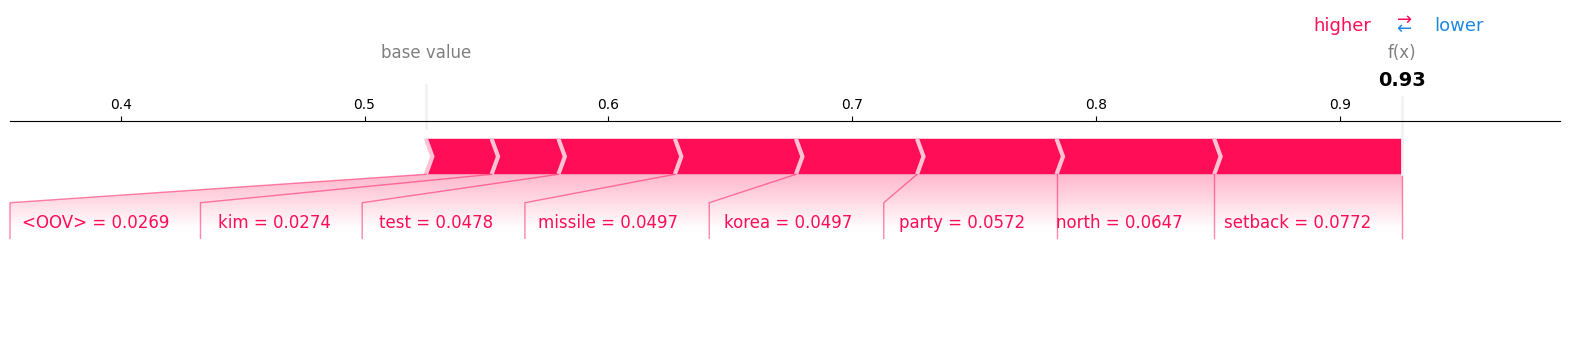

In [30]:
# =========================
# Definir índice da mesma instância usada no LIME
# =========================

lime_idx = 499

if lime_idx >= len(X_test_pad):
    raise ValueError("lime_idx fora do intervalo")

# Instância
X_instance = X_test_pad[lime_idx:lime_idx+1]

# =========================
# Descobrir classe predita automaticamente
# =========================

pred_probs = model.predict(X_instance)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]

# =========================
# Criar função para explicar classe predita
# =========================

def predict_fn(x):
    preds = model.predict(x)
    return preds[:, pred_class_idx]

# =========================
# Criar background
# =========================

background_size = 100
background = X_train_pad[
    np.random.choice(
        X_train_pad.shape[0],
        min(background_size, X_train_pad.shape[0]),
        replace=False
    )
]

# =========================
# Criar explainer
# =========================

explainer = shap.KernelExplainer(predict_fn, background)

# =========================
# Calcular SHAP values
# =========================

shap_values = explainer.shap_values(X_instance)

shap_values = np.array(shap_values[0]).reshape(-1)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# =========================
# Converter tokens → palavras
# =========================

tokens = X_instance[0]

words = [
    tokenizer.index_word.get(int(token), "")
    for token in tokens
]

# =========================
# Remover PAD
# =========================

valid_indices = [i for i, w in enumerate(words) if w != ""]

words = [words[i] for i in valid_indices]
shap_values = shap_values[valid_indices]

# =========================
# Ordenar por impacto absoluto
# =========================

sorted_indices = np.argsort(np.abs(shap_values))[::-1]

top_k = 15
sorted_indices = sorted_indices[:top_k]

words = [words[i] for i in sorted_indices]
shap_values = shap_values[sorted_indices]

# =========================
# Criar labels formatados: [palavra = valor]
# =========================

# Criamos uma lista de strings combinando a palavra e o valor do SHAP formatado
formatted_labels = [
    f"{word} = {val:.4f}" 
    for word, val in zip(words, shap_values)
]

# =========================
# Force plot final com labels customizados
# =========================

shap.force_plot(
    expected_value, 
    shap_values, 
    feature_names=formatted_labels, # Usamos a lista formatada aqui
    matplotlib=True
)